# PyTorch + LSDB on Dask: how to get the model onto the workers

Prototype: train a small PyTorch photo-z regressor on an LSDB catalog, then run inference
partition-by-partition. The focus is **how the model gets onto the Dask workers**:

| | Strategy | Mechanism |
|---|---|---|
| A | Pass the model directly | `cat.map_partitions(f, model=model)`: the model is pickled into every task |
| B | `dask.delayed(model)` | Model becomes a graph node, shipped once as a dependency |
| C | `client.scatter(model, broadcast=True)` | Model is put in each worker's memory ahead of time; tasks get a `Future` |
| D1 | `WorkerPlugin` | Each worker builds the model once at setup (e.g. from a checkpoint) and holds it |
| D2 | Lazy per-worker cache | First task on a worker loads the model, later tasks reuse it |

For each strategy we measure the **per-task payload** (bytes shipped with each task), the **shared
payload** (graph nodes shipped once and referenced by every task), the **wall time**, and the **number of
distinct model instances** that were actually used. We get that last one by giving the model a token that
is regenerated every time it's unpickled.

> **Runs against the LSDB branch `delayed-map-partitions-args`** (worktree `~/lincc/lsdb-delayed-args`,
> kernel *Python (lsdb delayed-args branch)*). On released LSDB, strategy B fails: `MapPartitions` embeds
> arguments literally, so the function receives an unevaluated `Delayed`. The branch unpacks dask
> collections in operation arguments into graph dependencies.

In [1]:
import os
import time
import uuid
from pathlib import Path

import cloudpickle
import dask
import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from distributed import Client, LocalCluster, WorkerPlugin, get_worker

print(f"lsdb {lsdb.__version__} from {Path(lsdb.__file__).parent} | dask {dask.__version__} | torch {torch.__version__}")

from lsdb.operations import lsdb_ops

assert hasattr(lsdb_ops, "UnpackedArgs"), "this notebook needs the delayed-map-partitions-args LSDB branch"

lsdb 0.11.1.dev15+gd327e4043 from /Users/dbranton/lincc/lsdb-delayed-args/src/lsdb | dask 2026.8.0 | torch 2.14.0


In [2]:
N_WORKERS, THREADS_PER_WORKER = 4, 2

# `processes=True` matters: with threads-only workers every strategy would share one address space and
# the differences below would disappear.
cluster = LocalCluster(n_workers=N_WORKERS, threads_per_worker=THREADS_PER_WORKER, processes=True)
client = Client(cluster)


# Torch defaults to one intra-op thread per core. With several Dask threads per worker, that
# oversubscribes the CPU badly, so pin torch to one thread on every worker.
def _limit_torch_threads():
    torch.set_num_threads(1)
    return torch.get_num_threads()


client.run(_limit_torch_threads)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55783,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:55794,Total threads: 2
Dashboard: http://127.0.0.1:55796/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:55786,


## 1. Synthetic catalog

Four magnitudes whose colors depend (nonlinearly) on a hidden `redshift`. We write the catalog to HATS
and reopen it so the task graph only contains file reads. (`lsdb.from_dataframe` embeds the data in the
graph. That makes the graph ~12 MiB on its own and would hide the model's contribution.)

In [3]:
def make_catalog_df(n=400_000, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.gamma(2.0, 0.3, n)
    base = rng.normal(20, 1.5, n)
    noise = lambda: rng.normal(0, 0.03, n)  # noqa: E731
    return pd.DataFrame(
        {
            "id": np.arange(n),
            "ra": rng.uniform(0, 360, n),
            "dec": np.degrees(np.arcsin(rng.uniform(-1, 1, n))),
            "mag_g": base + 0.9 * z + noise(),
            "mag_r": base + 0.4 * z**1.3 + noise(),
            "mag_i": base + 0.15 * np.sin(3 * z) + noise(),
            "mag_z": base - 0.2 * z + noise(),
            "redshift": z,
            "is_train": rng.uniform(size=n) < 0.8,
        }
    )


CATALOG_DIR = Path("lsdb_torch_demo/photoz_catalog")
if not CATALOG_DIR.exists():
    lsdb.from_dataframe(make_catalog_df(), ra_column="ra", dec_column="dec", partition_rows=10_000).to_hats(
        CATALOG_DIR
    )

cat = lsdb.open_catalog(CATALOG_DIR)
print(f"{len(cat):,} rows in {cat.npartitions} partitions")
cat.head()

400,000 rows in 48 partitions


Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

,id,ra,dec,mag_g,mag_r,mag_i,mag_z,redshift,is_train
_healpix_29,,,,,,,,,
27170352972672775,6,50.126351,15.463371,19.915504,19.969439,19.965888,19.933621,0.031923,False
41359144649965516,23,37.599077,17.860396,20.95287,20.321591,19.691521,19.521535,1.303948,True
44119041537554331,49,38.574481,21.159318,20.760096,20.344122,20.201581,19.943755,0.72105,True
36172192071639757,213,32.964417,10.352334,19.112569,18.931297,18.996463,18.795901,0.317966,False
61622620748497718,313,46.183906,30.877334,21.443997,21.000791,20.594454,20.376808,0.939813,True


## 2. Model

A small MLP on the three colors. Two details matter for distribution:

* `__setstate__` stamps a fresh `load_token` every time the model is **unpickled**. Counting distinct
  tokens in the output tells us exactly how many copies of the model the cluster built.
* `width` inflates the parameter count, so we can see how each strategy scales with model size.

The class is defined in the notebook, so cloudpickle ships it *by value*. In a real deployment it
would live in an installed package.

In [4]:
FEATURES = ["mag_g", "mag_r", "mag_i", "mag_z"]


def colors_tensor(df):
    m = df[FEATURES].to_numpy(dtype=np.float32)
    return torch.from_numpy(np.diff(m, axis=1) * -1)  # g-r, r-i, i-z


class PhotoZNet(torch.nn.Module):
    def __init__(self, width=64, depth=2):
        super().__init__()
        layers, d_in = [], 3
        for _ in range(depth):
            layers += [torch.nn.Linear(d_in, width), torch.nn.ReLU()]
            d_in = width
        layers.append(torch.nn.Linear(d_in, 1))
        self.body = torch.nn.Sequential(*layers)
        self.load_token = 0  # 0 == "the driver's original copy"

    def forward(self, x):
        return self.body(x).squeeze(-1)

    def __setstate__(self, state):
        super().__setstate__(state)
        self.load_token = uuid.uuid4().int >> 65  # fits in int64


def n_params(model):
    return sum(p.numel() for p in model.parameters())

## 3. Training

Two ways to train, both reading from the catalog:

**3a. Sample and train on the driver.** Often the right answer. A photo-z MLP doesn't need 400k rows, and
plain PyTorch on one machine is simple and fast.

**3b. Data-parallel on the workers.** Each training partition stays **in worker memory** (as futures).
Every step we broadcast the current weights, each partition computes the gradient of its summed loss,
and the driver adds them up and takes one optimizer step. Mathematically this is full-batch gradient
descent on the whole training set. The per-step broadcast is the same "get the model onto the workers"
question as inference, just asked on every step.

**Gotcha found while building this:** `client.scatter(state_dict)` does *not* ship one dict. It scatters
each tensor under its dict key (`"body.0.weight"`, …). Re-scattering new weights under the same keys
every step left workers with a mix of stale and fresh tensors, and training diverged (MSE ≈ 24 instead
of ≈ 0.001). Scatter `[state_dict]` (a one-element list) instead.

In [5]:
train_cat = cat.query("is_train")
test_cat = cat.query("~is_train")

# --- 3a: driver-side training on a sample -------------------------------------------------------------
sample = train_cat.random_sample(n=50_000, seed=1)  # returns an in-memory NestedFrame

torch.manual_seed(0)
model_local = PhotoZNet()
opt = torch.optim.Adam(model_local.parameters(), lr=3e-3)
X, y = colors_tensor(sample), torch.tensor(sample["redshift"].to_numpy(), dtype=torch.float32)
local_losses = []
t0 = time.perf_counter()
for epoch in range(30):
    perm = torch.randperm(len(X))
    for idx in perm.split(512):
        opt.zero_grad()
        loss = torch.nn.functional.mse_loss(model_local(X[idx]), y[idx])
        loss.backward()
        opt.step()
    local_losses.append(loss.item())
print(f"3a: trained on {len(sample):,} rows in {time.perf_counter() - t0:.1f}s, last batch MSE {local_losses[-1]:.4f}")

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

3a: trained on 50,000 rows in 1.0s, last batch MSE 0.0012


In [6]:
# --- 3b: data-parallel full-batch gradient descent over the whole training catalog --------------------
def partition_grad(df, state_dict, width, depth):
    """Summed-loss gradient for one partition. Returns (list[grad tensors], n_rows, summed loss)."""
    model = PhotoZNet(width, depth)
    model.load_state_dict(state_dict)
    if len(df) == 0:
        return [torch.zeros_like(p) for p in model.parameters()], 0, 0.0
    loss = torch.nn.functional.mse_loss(
        model(colors_tensor(df)), torch.tensor(df["redshift"].to_numpy(), dtype=torch.float32), reduction="sum"
    )
    loss.backward()
    return [p.grad for p in model.parameters()], len(df), loss.item()


# Materialize the training partitions on the workers once; they stay there for every step.
train_parts = client.compute(train_cat.to_delayed())
print(f"{len(train_parts)} training partitions pinned in worker memory")

torch.manual_seed(0)
model_dp = PhotoZNet()
opt = torch.optim.Adam(model_dp.parameters(), lr=1e-2)
dp_losses = []
t0 = time.perf_counter()
for step in range(150):
    # One broadcast per step: each worker receives the weights once, and every task on it shares them.
    # NB: wrap the dict in a list! `client.scatter(some_dict)` scatters each *value* under its dict key
    # ("body.0.weight", ...), so every step would reuse the same keys and workers keep stale weights.
    [w] = client.scatter([model_dp.state_dict()], broadcast=True, hash=False)
    results = client.gather([client.submit(partition_grad, part, w, 64, 2, pure=False) for part in train_parts])
    n_total = sum(r[1] for r in results)
    opt.zero_grad()
    for p, *grads in zip(model_dp.parameters(), *(r[0] for r in results)):
        p.grad = torch.stack(grads).sum(0) / n_total
    opt.step()
    dp_losses.append(sum(r[2] for r in results) / n_total)
print(f"3b: 150 full-batch steps over {n_total:,} rows in {time.perf_counter() - t0:.1f}s, MSE {dp_losses[-1]:.4f}")
del train_parts

48 training partitions pinned in worker memory


3b: 150 full-batch steps over 320,237 rows in 66.5s, MSE 0.0013


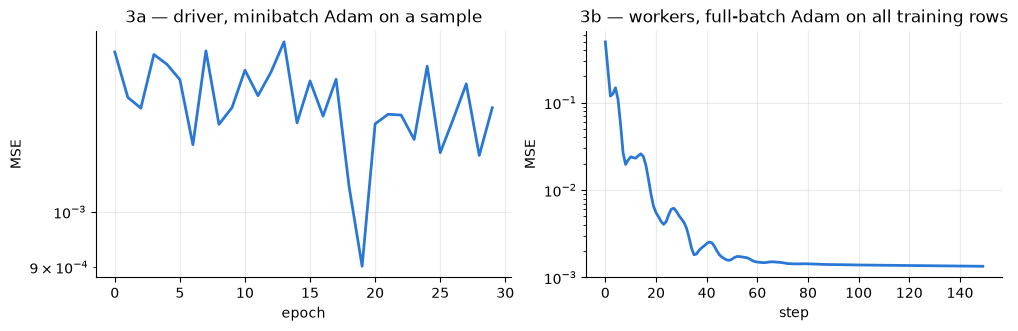

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
for ax, losses, title, xlabel in [
    (axes[0], local_losses, "3a — driver, minibatch Adam on a sample", "epoch"),
    (axes[1], dp_losses, "3b — workers, full-batch Adam on all training rows", "step"),
]:
    ax.plot(losses, color="#2a78d6", lw=2)
    ax.set(title=title, xlabel=xlabel, ylabel="MSE", yscale="log")
    ax.grid(alpha=0.25, lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. Inference: the distribution strategies

Every strategy runs the same kernel, `predict(df, model)`. It also reports the worker PID and the model's
`load_token`, so we can count how many model instances were used.

In [8]:
PRED_META = pd.DataFrame(
    {
        "id": pd.Series(dtype="int64"),
        "z_pred": pd.Series(dtype="float32"),
        "pid": pd.Series(dtype="int64"),
        "load_token": pd.Series(dtype="int64"),
    }
)


def predict(df, model):
    with torch.no_grad():
        z = model(colors_tensor(df)).numpy() if len(df) else np.zeros(0, np.float32)
    return pd.DataFrame(
        {"id": df["id"].to_numpy(), "z_pred": z, "pid": os.getpid(), "load_token": model.load_token}, index=df.index
    )


def graph_payload(catalog, base=None):
    """Pickled bytes of (a) the final-layer tasks, i.e. what's shipped with every partition task, and
    (b) any other nodes added on top of `base` (e.g. a `dask.delayed` model), which are shipped once."""
    base = test_cat if base is None else base
    built = catalog._operation.build()
    final_keys = set(built.pixel_to_key_map.values())
    base_keys = set(base._operation.build().graph)
    per_task = sum(len(cloudpickle.dumps(built.graph[k])) for k in final_keys)
    shared = sum(len(cloudpickle.dumps(v)) for k, v in built.graph.items() if k not in final_keys | base_keys)
    return per_task, shared


def run(name, pred_cat):
    payload, shared = graph_payload(pred_cat)
    t0 = time.perf_counter()
    out = pred_cat.compute()
    dt = time.perf_counter() - t0
    return out, {
        "strategy": name,
        "payload_MB": payload / 1e6,
        "shared_MB": shared / 1e6,
        "wall_s": dt,
        "model_instances": out.groupby(["pid", "load_token"]).ngroups,
        "workers_used": out["pid"].nunique(),
    }

### A. Pass the model directly
The model goes into each task's arguments, so it is serialized once **per partition** and deserialized
once per task.

In [9]:
model = model_dp.eval()
print(f"model params: {n_params(model):,}")
pred_A, row = run("A: direct kwarg", test_cat.map_partitions(predict, model=model, meta=PRED_META))
row

model params: 4,481


Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

{'strategy': 'A: direct kwarg',
 'payload_MB': 1.359936,
 'shared_MB': 0.0,
 'wall_s': 1.4318510829471052,
 'model_instances': 48,
 'workers_used': 4}

### B. `dask.delayed(model)`

The model becomes **its own node in the task graph**, and each partition task gets a `TaskRef` to it. The
scheduler runs that node once, on one worker. Other workers fetch the result from their peers the first
time one of their tasks needs it, and it stays in worker memory for the rest of the computation. There's no
registration step and nothing to clean up afterwards: the model is released when the computation finishes.

`meta` is required. LSDB can't run the function locally on an unevaluated `Delayed` to infer it:

In [10]:
try:
    test_cat.map_partitions(predict, model=dask.delayed(model))
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Cannot infer meta for MapPartitions when dask collections (e.g. dask.delayed objects) are passed as arguments, since the function can't be run on them locally. Please supply a meta for your function.


In [11]:
pred_B, row_B = run("B: dask.delayed(model)", test_cat.map_partitions(predict, model=dask.delayed(model), meta=PRED_META))
row_B

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

{'strategy': 'B: dask.delayed(model)',
 'payload_MB': 0.220128,
 'shared_MB': 0.023512,
 'wall_s': 0.9922248339280486,
 'model_instances': 4,
 'workers_used': 4}

Delayed values can also be nested inside other arguments, e.g. `config={"model": dask.delayed(model)}`.
They also work with `include_pixel=True`, `compute_single_partition=True` (resolved locally with
`dask.compute`), `.partitions[...]`, `to_dask_dataframe()` and `to_delayed()`.

### C. `client.scatter(model, broadcast=True)`

Push the model into every worker's memory up front, then pass the `Future` like any argument. Each
task's payload is just a key. On a worker, every task gets **the same in-memory object**, so it is
deserialized once per worker. The torch model isn't modified during inference, so sharing it across
threads is fine. (Don't share one model between threads for *training*.)

In [12]:
model_future = client.scatter(model, broadcast=True)
pred_C, row_C = run("C: scatter(broadcast=True)", test_cat.map_partitions(predict, model=model_future, meta=PRED_META))
row_C

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

{'strategy': 'C: scatter(broadcast=True)',
 'payload_MB': 0.221376,
 'shared_MB': 0.0,
 'wall_s': 0.929200999904424,
 'model_instances': 4,
 'workers_used': 4}

### D1. `WorkerPlugin`: set the model up on each worker once

This is the "manual" path. A plugin's `setup(worker)` runs once on every current **and future** worker
(so it survives autoscaling and worker restarts). Here it loads a checkpoint from a shared path, which
is how you'd do it on HPC or cloud storage. The task function finds the model through `get_worker()`.
Nothing model-related is in the graph at all.

To update the model (e.g. after retraining), call `register_plugin` again with the same name. Dask
tears down the old plugin and sets up the new one.

In [13]:
CKPT = Path("lsdb_torch_demo/photoz.pt").resolve()
torch.save({"width": 64, "depth": 2, "state_dict": model.state_dict()}, CKPT)


class TorchModelPlugin(WorkerPlugin):
    def __init__(self, name, checkpoint_path):
        self.name = name  # plugins are keyed by name on the worker
        self.checkpoint_path = str(checkpoint_path)
        self.model = None

    def setup(self, worker):
        torch.set_num_threads(1)
        ckpt = torch.load(self.checkpoint_path, map_location="cpu")
        model = PhotoZNet(ckpt["width"], ckpt["depth"])
        model.load_state_dict(ckpt["state_dict"])
        model.load_token = uuid.uuid4().int >> 65
        self.model = model.eval()

    def teardown(self, worker):
        self.model = None


def predict_with_plugin(df, plugin_name):
    return predict(df, get_worker().plugins[plugin_name].model)


client.register_plugin(TorchModelPlugin("photoz-model", CKPT))
pred_D1, row_D1 = run(
    "D1: WorkerPlugin", test_cat.map_partitions(predict_with_plugin, plugin_name="photoz-model", meta=PRED_META)
)
row_D1

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

{'strategy': 'D1: WorkerPlugin',
 'payload_MB': 0.241056,
 'shared_MB': 0.0,
 'wall_s': 0.9735251669771969,
 'model_instances': 4,
 'workers_used': 4}

### D2. Lazy per-worker cache

Same idea without registering anything: the first task on each worker loads the checkpoint and caches
it **on the `Worker` object**. Later tasks reuse it. The lock stops two threads on one worker from
loading at the same time.

**Gotcha: don't use `@functools.lru_cache` on a notebook-defined loader.** cloudpickle ships plain
`__main__` functions *by value*, but an `lru_cache` wrapper is pickled **by reference**
(`__main__._load_ckpt_cached`). The worker's `__main__` isn't your notebook, so deserializing the task
raises `AttributeError: Can't get attribute '_load_ckpt_cached' on <module '__main__'>`. The worker
process dies, the nanny restarts it, the task is resubmitted, and **`compute()` hangs indefinitely** with
no exception reaching the client. (It works by accident from a `python script.py`, because spawned
workers re-import the script as `__main__`.) An `lru_cache` is fine if the loader lives in an importable
module. Otherwise cache on the worker as done here.

In [14]:
def _load_ckpt(path):
    ckpt = torch.load(path, map_location="cpu")
    m = PhotoZNet(ckpt["width"], ckpt["depth"])
    m.load_state_dict(ckpt["state_dict"])
    m.load_token = uuid.uuid4().int >> 65
    return m.eval()


def predict_lazy(df, checkpoint_path):
    worker = get_worker()
    cache = worker.__dict__.setdefault("_torch_model_cache", {})
    if checkpoint_path not in cache:
        with worker.__dict__.setdefault("_torch_model_lock", __import__("threading").Lock()):
            if checkpoint_path not in cache:
                cache[checkpoint_path] = _load_ckpt(checkpoint_path)
    return predict(df, cache[checkpoint_path])


pred_D2, row_D2 = run(
    "D2: lazy worker cache", test_cat.map_partitions(predict_lazy, checkpoint_path=str(CKPT), meta=PRED_META)
)
row_D2

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

{'strategy': 'D2: lazy worker cache',
 'payload_MB': 0.386304,
 'shared_MB': 0.0,
 'wall_s': 1.3769785407930613,
 'model_instances': 4,
 'workers_used': 4}

### Sanity check: every strategy gives identical predictions

all strategies agree


Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

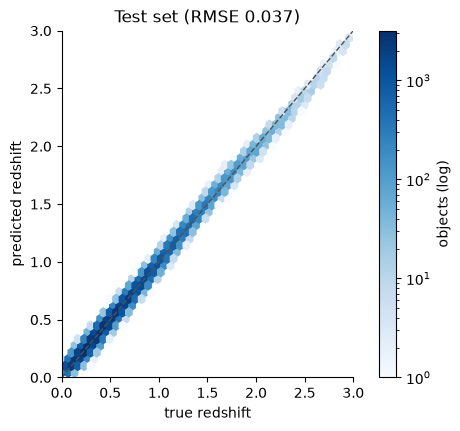

In [15]:
ref = pred_A.set_index("id")["z_pred"].sort_index()
for name, p in [("B", pred_B), ("C", pred_C), ("D1", pred_D1), ("D2", pred_D2)]:
    np.testing.assert_allclose(p.set_index("id")["z_pred"].sort_index(), ref, rtol=1e-6)
print("all strategies agree")

truth = test_cat.compute()[["id", "redshift"]].merge(pred_A[["id", "z_pred"]], on="id")
rmse = np.sqrt(np.mean((truth.z_pred - truth.redshift) ** 2))
fig, ax = plt.subplots(figsize=(4.5, 4.2), constrained_layout=True)
hb = ax.hexbin(truth.redshift, truth.z_pred, gridsize=60, bins="log", cmap="Blues", mincnt=1)
ax.plot([0, 3], [0, 3], color="#52514e", lw=1, ls="--")
ax.set(xlim=(0, 3), ylim=(0, 3), xlabel="true redshift", ylabel="predicted redshift", title=f"Test set (RMSE {rmse:.3f})")
fig.colorbar(hb, ax=ax, label="objects (log)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 5. Scaling with model size

The default model is tiny (~4k params), so every strategy costs about the same. Now we repeat the
comparison with a wider model (random weights; only the plumbing matters here) at ~8 MB and ~34 MB.

Strategy A runs last within each size. In 3 of our 4 runs (notebook and a standalone reproduction),
repeated direct-kwarg computations with the ~34 MB model **killed a worker process**
("Worker process died unexpectedly"), and it wasn't replaced. Worker memory was ~1.1 GiB, far below the
8 GiB limit, and there was no memory-budget warning, so the cause is still undetermined. Every later
strategy then ran on 3 workers. Watch the `workers_used` column.

In [16]:
rows = [row, row_B, row_C, row_D1, row_D2]
bench = []
for width in [1024, 2048]:
    big = PhotoZNet(width=width, depth=3).eval()
    mb = n_params(big) * 4 / 1e6
    ckpt = Path(f"lsdb_torch_demo/photoz_w{width}.pt").resolve()
    torch.save({"width": width, "depth": 3, "state_dict": big.state_dict()}, ckpt)

    # A runs last: repeated direct-kwarg runs with the large model can kill a worker (see below)
    cases = {
        "B: dask.delayed(model)": lambda: test_cat.map_partitions(predict, model=dask.delayed(big), meta=PRED_META),
        "C: scatter(broadcast=True)": lambda: test_cat.map_partitions(
            predict, model=client.scatter(big, broadcast=True), meta=PRED_META
        ),
        "D1: WorkerPlugin": lambda: (
            client.register_plugin(TorchModelPlugin(f"photoz-w{width}", ckpt)),
            test_cat.map_partitions(predict_with_plugin, plugin_name=f"photoz-w{width}", meta=PRED_META),
        )[1],
        "D2: lazy worker cache": lambda: test_cat.map_partitions(predict_lazy, checkpoint_path=str(ckpt), meta=PRED_META),
        "A: direct kwarg": lambda: test_cat.map_partitions(predict, model=big, meta=PRED_META),
    }
    for name, build in cases.items():
        t_setup = time.perf_counter()
        pc = build()
        setup_s = time.perf_counter() - t_setup
        _, r = run(name, pc)
        r.update(model_MB=round(mb, 1), setup_s=setup_s)
        bench.append(r)

results = pd.DataFrame(rows).assign(model_MB=round(n_params(model) * 4 / 1e6, 3), setup_s=np.nan)
results = pd.concat([results, pd.DataFrame(bench)], ignore_index=True)
cols = ["model_MB", "strategy", "payload_MB", "shared_MB", "setup_s", "wall_s", "model_instances", "workers_used"]
print("workers alive:", len(client.scheduler_info()["workers"]))
results[cols].round(3)

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

...

Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

/Users/dbranton/lincc/lsdb-delayed-args/.venv/lib/python3.12/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 32.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computing Catalog:   0%|          | 0/48 [00:00<?, ?it/s]

workers alive: 4


,model_MB,strategy,payload_MB,shared_MB,setup_s,wall_s,model_instances,workers_used
0,0.018,A: direct kwarg,1.360,0.000,NaN,1.432,48,4
1,0.018,B: dask.delayed(model),0.220,0.024,NaN,0.992,4,4
2,0.018,C: scatter(broadcast=True),0.221,0.000,NaN,0.929,4,4
3,0.018,D1: WorkerPlugin,0.241,0.000,NaN,0.974,4,4
4,0.018,D2: lazy worker cache,0.386,0.000,NaN,1.377,4,4
5,8.400,B: dask.delayed(model),0.220,8.424,0.001,1.206,4,4
6,8.400,C: scatter(broadcast=True),0.221,0.000,0.083,1.340,4,4
7,8.400,D1: WorkerPlugin,0.241,0.000,0.016,1.115,4,4
8,8.400,D2: lazy worker cache,0.387,0.000,0.001,1.467,4,4
9,8.400,A: direct kwarg,404.583,0.000,0.001,3.252,48,4


## 6. GPU inference (D1 / D2 on an accelerator)

Shipping a pickled model (A/B/C) leaves the move to the GPU to each task. In the worker-side strategies the
model is **built directly on the worker's device, once**, and anything expensive happens then, before the
first partition arrives: CUDA context creation, kernel/shader compilation, warm-up, and (not done here)
`torch.compile` or half precision.

* `worker_device(worker)` picks the worker's accelerator: CUDA, then Apple MPS, then CPU. With
  `dask_cuda.LocalCUDACluster`, each worker sees exactly one GPU (via `CUDA_VISIBLE_DEVICES`), so it is
  always `cuda:0`. With a plain `LocalCluster` on a multi-GPU node we spread workers by name.
  (`zlib.crc32`, not `hash()`: string hashing is randomized per process.)
* `torch.load(..., map_location=device)` puts the weights straight on the device. Nothing GPU-resident is
  ever pickled.
* `predict_on_device` feeds each partition in fixed-size batches, so GPU memory is bounded however big a
  HEALPix partition is. It also records the model time, so we can separate GPU compute from I/O and
  scheduling.
* One thread per worker. Several threads would put several partitions on the GPU at once, for little
  gain.

**Gotcha:** in a notebook, any function that references `torch.backends.mps` can't be cloudpickled
(`TypeError: cannot pickle 'GenericModule' object`), so it can't be shipped to workers. Use the equivalent
`torch.mps.is_available()`.

In [17]:
import threading
import zlib


def worker_device(worker=None):
    """The accelerator a worker should use: its own CUDA GPU, else Apple MPS, else CPU."""
    if torch.cuda.is_available():
        n = torch.cuda.device_count()
        idx = 0 if n == 1 or worker is None else zlib.crc32(str(worker.name).encode()) % n
        return torch.device("cuda", idx)
    if torch.mps.is_available():  # not torch.backends.mps: that breaks cloudpickle (see above)
        return torch.device("mps")
    return torch.device("cpu")


def sync_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


def load_on_device(checkpoint_path, device, warmup_rows=4096):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = PhotoZNet(ckpt["width"], ckpt["depth"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.load_token = uuid.uuid4().int >> 65
    model.eval()
    with torch.no_grad():  # warm-up so the first partition doesn't pay for kernel compilation
        model(torch.zeros(warmup_rows, 3, device=device))
    sync_device(device)
    return model


DEVICE_META = PRED_META.assign(device=pd.Series(dtype=str), model_s=pd.Series(dtype="float64"))


def predict_on_device(df, model, batch_size=65_536):
    device = next(model.parameters()).device
    x = colors_tensor(df)
    out = []
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in x.split(batch_size):
            out.append(model(batch.to(device, non_blocking=True)).float().cpu())
    model_s = time.perf_counter() - t0  # .cpu() waits for the device, so this includes the GPU work
    z = torch.cat(out).numpy() if out else np.zeros(0, np.float32)
    return pd.DataFrame(
        {
            "id": df["id"].to_numpy(),
            "z_pred": z,
            "pid": os.getpid(),
            "load_token": model.load_token,
            "device": str(device),
            # the partition's model time spread over its rows, so summing the column gives the total
            "model_s": model_s / max(len(df), 1),
        },
        index=df.index,
    )


class DeviceModelPlugin(WorkerPlugin):
    """D1 on an accelerator: build the model on the worker's device once, at worker setup."""

    def __init__(self, name, checkpoint_path, device=None):
        self.name = name
        self.checkpoint_path = str(checkpoint_path)
        self.requested_device = device  # None = the worker's accelerator
        self.model = None
        self.setup_s = None

    def setup(self, worker):
        torch.set_num_threads(1)
        device = torch.device(self.requested_device) if self.requested_device else worker_device(worker)
        t0 = time.perf_counter()
        self.model = load_on_device(self.checkpoint_path, device)
        self.setup_s = time.perf_counter() - t0

    def teardown(self, worker):
        device = next(self.model.parameters()).device if self.model is not None else None
        self.model = None
        if device is not None and device.type == "cuda":
            torch.cuda.empty_cache()
        elif device is not None and device.type == "mps":
            torch.mps.empty_cache()


def predict_with_device_plugin(df, plugin_name):
    return predict_on_device(df, get_worker().plugins[plugin_name].model)


def predict_lazy_device(df, checkpoint_path):
    """D2 on an accelerator: the first task on each worker loads the model onto the worker's device."""
    worker = get_worker()
    cache = worker.__dict__.setdefault("_torch_device_models", {})
    if checkpoint_path not in cache:
        with worker.__dict__.setdefault("_torch_device_lock", threading.Lock()):
            if checkpoint_path not in cache:
                cache[checkpoint_path] = load_on_device(checkpoint_path, worker_device(worker))
    return predict_on_device(df, cache[checkpoint_path])

A GPU-shaped cluster replaces the CPU one: one single-threaded worker per GPU.

* **CUDA with `dask-cuda`:** `LocalCUDACluster` handles GPU pinning.
* **CUDA without it:** a `LocalCluster` with one worker per device.
* **Apple Silicon:** two processes sharing the one MPS GPU.
* **No accelerator:** it still runs, just on CPU.

The CUDA branches are untested here; this machine only has MPS.

In [18]:
import importlib.util

client.close()
cluster.close()

accel = worker_device()
if accel.type == "cuda" and importlib.util.find_spec("dask_cuda"):
    from dask_cuda import LocalCUDACluster

    cluster = LocalCUDACluster(threads_per_worker=1)
elif accel.type == "cuda":
    cluster = LocalCluster(n_workers=torch.cuda.device_count(), threads_per_worker=1)
else:
    cluster = LocalCluster(n_workers=2, threads_per_worker=1)
client = Client(cluster)
client.run(_limit_torch_threads)
print(f"driver sees accelerator: {accel} | cluster: {type(cluster).__name__} x {len(client.scheduler_info()['workers'])} workers")

driver sees accelerator: mps | cluster: LocalCluster x 2 workers


Same models, same worker-side strategies, run on the CPU and on the accelerator. `model_s` is time spent
inside the model, summed over partitions. `wall_s` also includes Parquet reads and scheduling.

In [19]:
gpu_rows, gpu_preds = [], {}
for width in [2048, 4096]:
    torch.manual_seed(0)
    big = PhotoZNet(width=width, depth=3).eval()
    mb = n_params(big) * 4 / 1e6
    ckpt = Path(f"lsdb_torch_demo/photoz_w{width}.pt").resolve()
    torch.save({"width": width, "depth": 3, "state_dict": big.state_dict()}, ckpt)

    for strategy, device in [("D1: WorkerPlugin", "cpu"), ("D1: WorkerPlugin", None), ("D2: lazy worker cache", None)]:
        setup_s = np.nan
        if strategy.startswith("D1"):
            name = f"photoz-dev-{width}-{device or 'accel'}"
            client.register_plugin(DeviceModelPlugin(name, ckpt, device=device))
            setup_s = max(client.run(lambda dask_worker, n=name: dask_worker.plugins[n].setup_s).values())
            pred_cat = test_cat.map_partitions(predict_with_device_plugin, plugin_name=name, meta=DEVICE_META)
        else:
            pred_cat = test_cat.map_partitions(predict_lazy_device, checkpoint_path=str(ckpt), meta=DEVICE_META)
        t0 = time.perf_counter()
        out = pred_cat.compute(progress_bar=False)
        wall_s = time.perf_counter() - t0
        if strategy.startswith("D1"):
            client.unregister_worker_plugin(name)
        devices = ",".join(sorted(out["device"].unique()))
        gpu_preds[(width, strategy, devices)] = out.set_index("id")["z_pred"].sort_index()
        gpu_rows.append(
            {
                "model_MB": round(mb, 1),
                "strategy": strategy,
                "device": devices,
                "setup_s": setup_s,
                "wall_s": wall_s,
                "model_s": out["model_s"].sum(),
                "model_instances": out.groupby(["pid", "load_token"]).ngroups,
                "workers_used": out["pid"].nunique(),
            }
        )

gpu_results = pd.DataFrame(gpu_rows)
gpu_results.round(3)

,model_MB,strategy,device,setup_s,wall_s,model_s,model_instances,workers_used
0,33.6,D1: WorkerPlugin,cpu,0.146,3.940,1.966,2,2
1,33.6,D1: WorkerPlugin,mps:0,0.291,1.482,1.043,2,2
2,33.6,D2: lazy worker cache,mps:0,NaN,2.203,0.878,2,2
3,134.3,D1: WorkerPlugin,cpu,0.592,4.254,6.159,2,2
4,134.3,D1: WorkerPlugin,mps:0,0.425,2.755,3.544,2,2
5,134.3,D2: lazy worker cache,mps:0,NaN,3.738,3.474,2,2


In [20]:
for width in [2048, 4096]:
    preds = [p for (w, _, _), p in gpu_preds.items() if w == width]
    worst = max(float(np.abs(p - preds[0]).max()) for p in preds[1:])
    print(f"width {width}: max |prediction difference| across devices = {worst:.2e}")

width 2048: max |prediction difference| across devices = 9.13e-08
width 4096: max |prediction difference| across devices = 1.17e-07


**Reading the numbers:**
* Every accelerator run uses **one model instance per worker**, built on the device once. `setup_s` for D1
  includes the warm-up; for D2 that cost lands in the first partition on each worker instead.
* How much the GPU helps depends on the model and hardware. On Apple Silicon the MPS GPU is integrated and
  shared by both workers, and the CPU is itself fast at matrix math, so the gain is modest and grows with
  model size. On a discrete CUDA GPU, a compute-heavy model gets a much bigger speedup. When `model_s` is
  small next to `wall_s`, Parquet reads and scheduling dominate, and a faster device won't help.
* GPU and CPU predictions differ only at the level of float32 rounding.

**Mixed CPU/GPU clusters:** tag GPU workers with a resource (e.g. `dask worker ... --resources "GPU=1"`) and
annotate the computation. Every LSDB task in it, reads included, then runs on GPU workers. This was
verified with a simulated resource-tagged worker; the annotation can wrap just the `compute()` call:

```python
with dask.annotate(resources={"GPU": 1}):
    preds = cat.map_partitions(predict_with_device_plugin, plugin_name="photoz", meta=DEVICE_META).compute()
```

In such a cluster, D1's `setup()` should skip workers without a GPU (the plugin runs on all of them), or use
D2, which only loads where inference actually runs.

## 7. Takeaways

* **A (direct kwarg)** is fine for small models. Its cost grows as *model size × number of partitions*
  in payload and deserialization. Once there are many partitions or the model is large, it is the
  slowest option and it multiplies scheduler memory. Dask also warns about large graphs. With the ~34 MB
  model it also **killed a worker process** in 3 of our 4 runs (cause undetermined; not the memory limit).
* **B (`dask.delayed`)** now works through `Catalog.map_partitions` on the branch, and it performs like
  scatter: one model instance per worker and a tiny per-task payload. It's the most "Dask-native" option.
  It needs no `Client` handle, works with any scheduler, and the model's lifetime is tied to the
  computation. The trade-off: the model travels **inside the graph** once (the `shared_MB` column, and Dask's
  "large graph" warning), so the client has to hold and send it. Each new `compute()` ships it again, whereas
  a scattered future can be reused across computations.
* **C (scatter broadcast)** is the simplest correct choice from a notebook. There's one copy per worker,
  it's trivial to refresh after retraining (scatter again), and it's what the data-parallel training
  loop uses every step. The drawbacks: the driver has to hold the model and push it to every worker, and
  workers that join later fetch it from peers on demand.
* **D1 (WorkerPlugin)** is the most "production" option: nothing model-related is in the graph, it loads
  from shared storage (so the driver never touches the weights), and it re-runs on new or restarted
  workers. It costs a bit more ceremony, and the task function has to know the plugin name.
* **D2 (lazy cache)** gets D1's benefits with zero registration. Put the cache on the worker or in an
  importable module, **not** in an `lru_cache` on a notebook-defined function (that one hangs the cluster).
* **Training (3b)** uses strategy C's mechanism every step. Keep the data persisted on the workers,
  broadcast only the weights, and reduce the gradients on the driver. The ~0.4 s/step here is mostly
  Dask round-trip overhead for 48 tasks. For real training, have each task do several local minibatch
  steps (local SGD / federated averaging) and average the weights, or hand off to `torch.distributed`.
  Beware `client.scatter(dict)` (see 3b).
* Regardless of strategy, **pin `torch.set_num_threads(1)`** (or match it to `threads_per_worker`) on the
  workers. Otherwise torch's intra-op threads fight Dask's threads.
* **For GPUs, prefer D1/D2** (section 6). They build the model on the worker's device once, with warm-up.
  A/B/C ship CPU weights that each task must move to the device, and a model pickled while on a GPU gets
  restored onto that same device index everywhere. Use one single-threaded worker per GPU, batch within
  partitions, and route with `dask.annotate(resources={"GPU": 1})` in mixed clusters.

In [21]:
client.close()
cluster.close()